<a href="https://colab.research.google.com/github/RjayBernales/SUS_Analysis/blob/main/Success_Error_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sample_logs.csv to sample_logs (15).csv

 Uploaded File:  sample_logs (15).csv

 Dataset Preview


,id,operation_type,status_code,status_group,message,created_at
0,1,CREATE,200,2xx Success,Operation successful,01/01/2026 0:00
1,2,READ,201,2xx Success,Operation successful,01/01/2026 1:00
2,3,UPDATE,202,2xx Success,Operation successful,01/01/2026 2:00
3,4,DELETE,203,2xx Success,Operation successful,01/01/2026 3:00
4,5,CREATE,204,2xx Success,Operation successful,01/01/2026 4:00



 Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              100 non-null    int64 
 1   operation_type  100 non-null    object
 2   status_code     100 non-null    int64 
 3   status_group    100 non-null    object
 4   message         100 non-null    object
 5   created_at      100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
None

 Missing Values
id                0
operation_type    0
status_code       0
status_group      0
message           0
created_at        0
dtype: int64

 Total Records
100
-------------------------------
Performance Metrics
Total Operations:  100
Successful Operations:  70
Client Errors: (4xx) 20
Server Errors: (5xx) 10
Total Errors:  30
Success Rate: 70.00%
Error Rate: 30.00%

 Daily Time Series Metrics


,total_operation,successful,client_errors,server_errors,total_errors,success_rate,error_rate
created_at,,,,,,,
01/01/2026,24,18,4,2,6,75.000000,25.000000
01/02/2026,24,17,5,2,7,70.833333,29.166667
01/03/2026,24,16,5,3,8,66.666667,33.333333
01/04/2026,24,18,4,2,6,75.000000,25.000000
01/05/2026,4,1,2,1,3,25.000000,75.000000


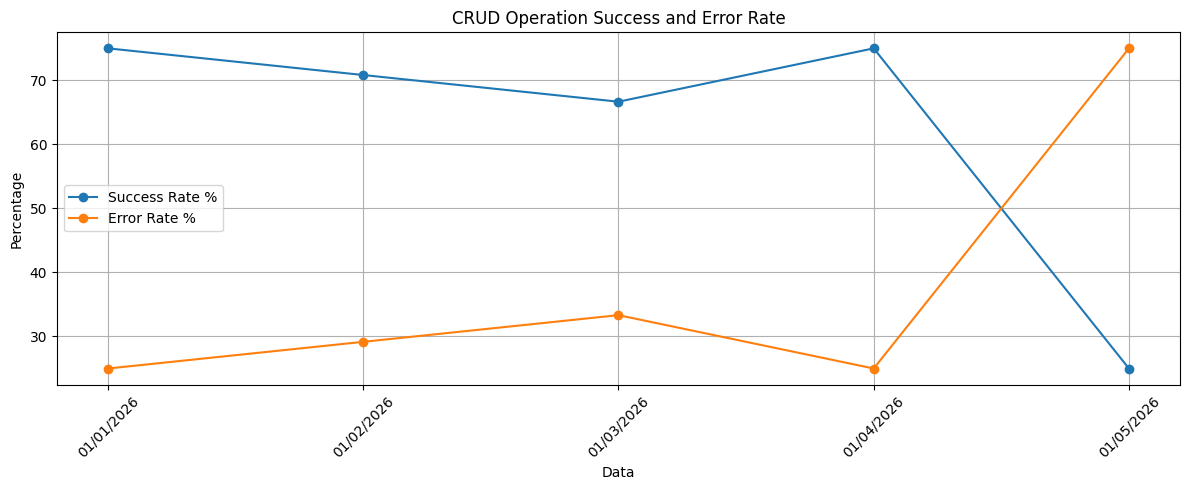

,total_operation,successful_operations,success_rate,error_rate
operation_type,,,,
CREATE,25,20,80.0,20.0
DELETE,25,15,60.0,40.0
READ,25,15,60.0,40.0
UPDATE,25,20,80.0,20.0


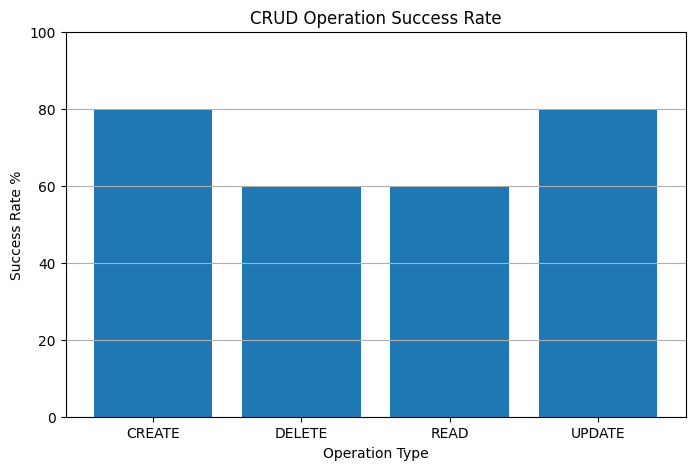


 HTTP Response Distribution


,0
status_code,
200,20
201,20
202,10
203,10
204,10
400,2
401,4
402,3
403,2


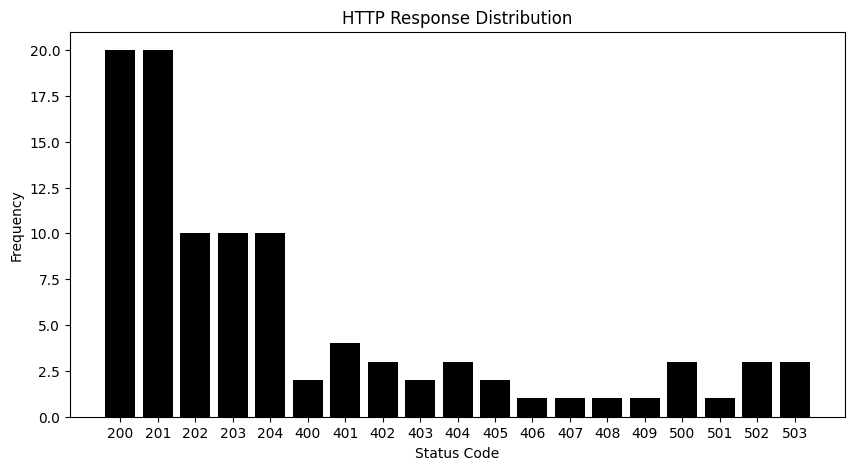

In [20]:
from numpy import astype
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

#File upload
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("\n Uploaded File: ", filename)

#Load dataset
df=pd.read_csv(filename)
print("\n Dataset Preview")
display(df.head())

#Data Validation
print("\n Dataset information")
print(df.info())
print("\n Missing Values")
print(df.isnull().sum())
print("\n Total Records")
print(len(df))

#Convert timestamp
df['created_at']=pd.to_datetime(df['created_at'])

#HTTP Responses
df['success']=df['status_code'].between(200,299)
df['client_error']=df['status_code'].between(400,499)
df['server_error']=df['status_code'].between(500,599)

#Performance Metrics
total_operation=len(df)
successful_operation=df['success'].sum()
client_errors=df['client_error'].sum()
server_errors=df['server_error'].sum()
total_errors=client_errors+server_errors
success_rate=(successful_operation/total_operation) * 100
error_rate=(total_errors/total_operation) * 100

#Visualization
print("-------------------------------")
print("Performance Metrics")
print("Total Operations: ", total_operation)
print("Successful Operations: ", successful_operation)
print("Client Errors: (4xx)", client_errors)
print("Server Errors: (5xx)", server_errors)
print("Total Errors: ", total_errors)
print(f"Success Rate: {success_rate:.2f}%")
print(f"Error Rate: {error_rate:.2f}%")

#DATA SERIES
daily_metrics=df.groupby(df['created_at'].dt.strftime('%m/%d/%Y')).agg(
    total_operation=('id', 'count'),
    successful=('success', 'sum'),
    client_errors=('client_error', 'sum'),
    server_errors=('server_error', 'sum'),
)

daily_metrics['total_errors']= daily_metrics['client_errors'] + daily_metrics['server_errors']
daily_metrics['success_rate']= (daily_metrics['successful'] / daily_metrics['total_operation']) * 100
daily_metrics['error_rate']= (daily_metrics['total_errors'] / daily_metrics['total_operation']) * 100

print('\n Daily Time Series Metrics')
display(daily_metrics)

#Time Series

plt.figure(figsize=(12,5))
plt.plot(
    daily_metrics.index,
    daily_metrics['success_rate'],
    marker='o',
    label="Success Rate %"
)

plt.plot(
    daily_metrics.index,
    daily_metrics['error_rate'],
    marker='o',
    label="Error Rate %"
)

plt.title('CRUD Operation Success and Error Rate')
plt.xlabel('Data')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#CRUD Count

crud_metrics=df.groupby('operation_type').agg(
    total_operation=('id', 'count'),
    successful_operations=('success', 'sum')
)

crud_metrics['success_rate']=(crud_metrics['successful_operations'] / crud_metrics['total_operation']) * 100
crud_metrics['error_rate']=(100 - crud_metrics['success_rate'])

display(crud_metrics)

#CRUD Count Barchart

plt.figure(figsize=(8,5))
plt.bar(crud_metrics.index,crud_metrics['success_rate'])
plt.title('CRUD Operation Success Rate')
plt.xlabel('Operation Type')
plt.ylabel('Success Rate %')
plt.ylim(0,100)
plt.grid(axis='y')
plt.show()

#HTTP Response
http_distribution = df.groupby('status_code').size()
print('\n HTTP Response Distribution')
display(http_distribution)

plt.figure(figsize=(10,5))
plt.bar(http_distribution.index.astype(str),
        http_distribution.values,
        color='black'
        )
plt.title('HTTP Response Distribution')
plt.xlabel('Status Code')
plt.ylabel('Frequency')
plt.show()
